# Milestone 1: Tabular Multi-Layer Perceptron (MLP)

This notebook covers the development of a predictive model for **product rating bands** using tabular metadata extracted from product attributes and aggregated reviews.

## Objective
Predict the product's average rating band (Low, Medium, High) based on product price, subcategory, brand/store, review count, and average helpful votes.

### Roadmap
1. **Environment Setup & Colab Compatibility**
2. **Data Loading & Preprocessing**
3. **Feature Engineering**: Extracting product-level features and aggregating review metrics
4. **Class Definition**: Discretizing ratings into balanced bands using training set quantiles (addressing rating imbalance)
5. **Baseline Model**: Train a Logistic Regression baseline
6. **Deep Learning Model**: Train a Keras Multilayer Perceptron (MLP) with regularization and early stopping
7. **Evaluation & Error Analysis**: Comparing models via accuracy, Macro F1-score, and confusion matrices

## 1. Setup, Environment Detection & Imports

In [ ]:
import sys
import os
from pathlib import Path

# Detect if running in Google Colab
IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    print("Running in Google Colab. Installing compatible datasets library (<3.0.0) and other packages...")
    !pip install "datasets>=2.16.0,<3.0.0" transformers diffusers accelerate gradio -q 2>/dev/null

    # Create folders
    os.makedirs('src', exist_ok=True)
    os.makedirs('data/processed', exist_ok=True)
    os.makedirs('data/plots', exist_ok=True)

    # Write data.py directly to Colab disk for imports
    # (We duplicate the clean version of data.py for self-contained execution in Colab)
    data_py_content = """import os
import json
import pandas as pd
import numpy as np
import requests
from pathlib import Path
from sklearn.model_selection import train_test_split
from datasets import load_dataset
import io
from PIL import Image
from tqdm import tqdm

def load_amazon_data(category="All_Beauty"):
    print(f"Loading reviews for {category}...")
    reviews_dataset = load_dataset("McAuley-Lab/Amazon-Reviews-2023", f"raw_review_{category}", trust_remote_code=True)
    reviews_df = pd.DataFrame(reviews_dataset['full'])

    print(f"Loading metadata for {category}...")
    meta_dataset = load_dataset("McAuley-Lab/Amazon-Reviews-2023", f"raw_meta_{category}", split="full", trust_remote_code=True)
    meta_df = pd.DataFrame(meta_dataset)
    return reviews_df, meta_df

def clean_data(reviews_df, meta_df):
    print("Cleaning metadata...")
    def clean_price(x):
        if pd.isna(x):
            return np.nan
        if isinstance(x, (int, float)):
            return float(x)
        x_str = str(x).replace('$', '').replace(',', '').strip()
        try:
            return float(x_str)
        except ValueError:
            return np.nan
    meta_df['price_cleaned'] = meta_df['price'].apply(clean_price)
    # Process images: extract the first image URL if it is a list of dicts/strings
    def extract_image_url(images_val):
        if not images_val or pd.isna(images_val):
            return None

        def first_string(val):
            if isinstance(val, list):
                if len(val) > 0:
                    first = val[0]
                    if isinstance(first, str):
                        return first
                    elif isinstance(first, dict) and 'large' in first:
                        return first['large']
            elif isinstance(val, str):
                return val
            return None

        if isinstance(images_val, dict):
            for key in ['large', 'hi_res', 'thumb']:
                if key in images_val:
                    res = first_string(images_val[key])
                    if res:
                        return res
            return None

        if isinstance(images_val, (list, np.ndarray)):
            return first_string(list(images_val))

        return None
    meta_df['image_url'] = meta_df['images'].apply(extract_image_url)

    def clean_description(desc):
        if isinstance(desc, list):
            return " ".join([str(d) for d in desc])
        if pd.isna(desc):
            return ""
        return str(desc)
    meta_df['description_cleaned'] = meta_df['description'].apply(clean_description)

    print("Cleaning reviews...")
    reviews_df['rating'] = pd.to_numeric(reviews_df['rating'], errors='coerce')
    vote_col = 'helpful_vote' if 'helpful_vote' in reviews_df.columns else 'helpful_votes'
    if vote_col in reviews_df.columns:
        reviews_df['helpful_votes'] = pd.to_numeric(reviews_df[vote_col], errors='coerce').fillna(0).astype(int)
    else:
        reviews_df['helpful_votes'] = 0
    reviews_df['text_cleaned'] = reviews_df['text'].fillna("")
    reviews_df['title_cleaned'] = reviews_df['title'].fillna("")
    return reviews_df, meta_df

def split_by_product(reviews_df, meta_df, train_ratio=0.7, val_ratio=0.15, test_ratio=0.15, random_seed=42):
    print("Splitting data by product...")
    prod_col = 'parent_asin' if ('parent_asin' in meta_df.columns and 'parent_asin' in reviews_df.columns) else 'asin'
    unique_products = list(set(meta_df[prod_col].unique()) & set(reviews_df[prod_col].unique()))

    train_prods, test_val_prods = train_test_split(unique_products, train_size=train_ratio, random_state=random_seed)
    val_relative_ratio = val_ratio / (val_ratio + test_ratio)
    val_prods, test_prods = train_test_split(test_val_prods, train_size=val_relative_ratio, random_state=random_seed)

    train_prods_set = set(train_prods)
    val_prods_set = set(val_prods)
    test_prods_set = set(test_prods)

    meta_train = meta_df[meta_df[prod_col].isin(train_prods_set)]
    meta_val = meta_df[meta_df[prod_col].isin(val_prods_set)]
    meta_test = meta_df[meta_df[prod_col].isin(test_prods_set)]

    reviews_train = reviews_df[reviews_df[prod_col].isin(train_prods_set)]
    reviews_val = reviews_df[reviews_df[prod_col].isin(val_prods_set)]
    reviews_test = reviews_df[reviews_df[prod_col].isin(test_prods_set)]
    return (reviews_train, meta_train), (reviews_val, meta_val), (reviews_test, meta_test)
"""
    with open('src/data.py', 'w', encoding='utf-8') as f:
        f.write(data_py_content)
    sys.path.append(os.path.abspath('src'))
    data_dir_path = 'data/processed'
    plots_dir_path = 'data/plots'
else:
    sys.path.append(os.path.abspath('../src'))
    data_dir_path = '../data/processed'
    plots_dir_path = '../data/plots'

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Sklearn tools
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, f1_score, confusion_matrix

# TensorFlow & Keras
import tensorflow as tf
from tensorflow import keras
from keras import layers, regularizers, callbacks

# Set styling
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (9, 5)
print(f"TensorFlow Version: {tf.__version__}")
print(f"Num GPUs Available: {len(tf.config.list_physical_devices('GPU'))}")

Running in Google Colab. Installing compatible datasets library (<3.0.0) and other packages...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 527.3/527.3 kB 27.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 177.6/177.6 kB 14.4 MB/s eta 0:00:00
TensorFlow Version: 2.20.0
Num GPUs Available: 1


## 2. Data Loading & Splits Preparation
If the data split parquet files are not cached locally, we run the loading, cleaning, and product-level split functions to write them. Otherwise, we load them directly from the cache.

In [ ]:
from data import load_amazon_data, clean_data, split_by_product

# Check if processed splits exist
train_reviews_path = Path(data_dir_path) / "reviews_train.parquet"
train_meta_path = Path(data_dir_path) / "meta_train.parquet"

if not (train_reviews_path.exists() and train_meta_path.exists()):
    print("Processed dataset splits not found. Loading and generating splits from scratch...")
    reviews_df, meta_df = load_amazon_data("All_Beauty")
    reviews_df, meta_df = clean_data(reviews_df, meta_df)

    splits = split_by_product(reviews_df, meta_df)
    (reviews_train, meta_train), (reviews_val, meta_val), (reviews_test, meta_test) = splits

    # Save splits
    os.makedirs(data_dir_path, exist_ok=True)
    reviews_train.to_parquet(Path(data_dir_path) / "reviews_train.parquet", index=False)
    reviews_val.to_parquet(Path(data_dir_path) / "reviews_val.parquet", index=False)
    reviews_test.to_parquet(Path(data_dir_path) / "reviews_test.parquet", index=False)

    meta_train.to_parquet(Path(data_dir_path) / "meta_train.parquet", index=False)
    meta_val.to_parquet(Path(data_dir_path) / "meta_val.parquet", index=False)
    meta_test.to_parquet(Path(data_dir_path) / "meta_test.parquet", index=False)
else:
    print("Loading processed splits from disk...")
    reviews_train = pd.read_parquet(Path(data_dir_path) / "reviews_train.parquet")
    reviews_val = pd.read_parquet(Path(data_dir_path) / "reviews_val.parquet")
    reviews_test = pd.read_parquet(Path(data_dir_path) / "reviews_test.parquet")

    meta_train = pd.read_parquet(Path(data_dir_path) / "meta_train.parquet")
    meta_val = pd.read_parquet(Path(data_dir_path) / "meta_val.parquet")
    meta_test = pd.read_parquet(Path(data_dir_path) / "meta_test.parquet")

print(f"Train set: {len(meta_train)} products, {len(reviews_train)} reviews")
print(f"Val set: {len(meta_val)} products, {len(reviews_val)} reviews")
print(f"Test set: {len(meta_test)} products, {len(reviews_test)} reviews")

Processed dataset splits not found. Loading and generating splits from scratch...
Loading reviews for All_Beauty...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Generating full split: 0 examples [00:00, ? examples/s]

Loading metadata for All_Beauty...


Generating full split:   0%|          | 0/112590 [00:00<?, ? examples/s]

Cleaning metadata...
Cleaning reviews...
Splitting data by product...
Train set: 78795 products, 495127 reviews
Val set: 16885 products, 99648 reviews
Test set: 16885 products, 106753 reviews


## 3. Feature Engineering & Dataset Aggregation
We need to create a product-level dataset from the review-level and metadata tables.
To prevent **data leakage**, we must aggregate reviews and extract metadata independently for the train, validation, and test splits.

### Features Extracted:
1. **`review_count`**: Total number of reviews written for this product.
2. **`mean_helpful_votes`**: Average helpful votes received by reviews of this product.
3. **`price_cleaned`**: Product price (numerical).
4. **`secondary_category`**: The subcategory path (e.g. "Hair Care", "Makeup") extracted from `categories` column.
5. **`store`**: Brand/Store name.

In [ ]:
def build_product_features(reviews_df, meta_df):
    # 1. Aggregate reviews at the product level (parent_asin)
    # We use parent_asin as the product identifier
    prod_col = 'parent_asin' if 'parent_asin' in reviews_df.columns else 'asin'

    reviews_agg = reviews_df.groupby(prod_col).agg(
        review_count=('rating', 'count'),
        mean_helpful_votes=('helpful_votes', 'mean')
    ).reset_index()

    # 2. Extract product subcategories (index 1 of categories list) and clean store names
    meta_features = meta_df.copy()

    def extract_subcat(cat_list):
        if isinstance(cat_list, (list, np.ndarray)) and len(cat_list) > 1:
            return str(cat_list[1])
        return "Unknown"

    meta_features['secondary_category'] = meta_features['categories'].apply(extract_subcat)
    meta_features['store_cleaned'] = meta_features['store'].fillna("Unknown").astype(str).str.lower().str.strip()

    # 3. Merge aggregated reviews with metadata features
    merged_df = pd.merge(meta_features, reviews_agg, on=prod_col, how='inner')

    # Keep only the columns needed for modeling
    columns_to_keep = [
        prod_col, 'price_cleaned', 'secondary_category', 'store_cleaned',
        'review_count', 'mean_helpful_votes', 'average_rating'
    ]
    return merged_df[columns_to_keep]

print("Building train features...")
train_features = build_product_features(reviews_train, meta_train)
print("Building validation features...")
val_features = build_product_features(reviews_val, meta_val)
print("Building test features...")
test_features = build_product_features(reviews_test, meta_test)

train_features.head()

Building train features...
Building validation features...
Building test features...


,parent_asin,price_cleaned,secondary_category,store_cleaned,review_count,mean_helpful_votes,average_rating
0,B01CUPMQZE,NaN,Unknown,howard products,5,0.400000,4.8
1,B088FKY3VD,NaN,Unknown,cherioll,11,3.090909,3.1
2,B07NGFDN6G,NaN,Unknown,precision,1,0.000000,4.3
3,B07G9GWFSM,6.99,Unknown,lurrose,1,0.000000,3.7
4,B08DNQTTQK,NaN,Unknown,maitys,3,5.333333,3.8


## 4. Class Discretization (Rating Bands)
Amazon ratings are highly imbalanced, with a vast majority of products receiving 5-star ratings. If we define fixed bins (e.g. 1-2, 3-4, 5), the classes will be highly skewed.

To build a robust classifier and ensure class-balanced evaluation metrics, we discretize the `average_rating` into three rating bands (**Low**, **Medium**, **High**) using **quantile thresholds (33rd and 66th percentiles) calculated on the training set**.

In [ ]:
# Calculate thresholds from training set average_rating
rating_vals = train_features['average_rating'].dropna().values
t1 = np.percentile(rating_vals, 33.3)
t2 = np.percentile(rating_vals, 66.6)
print(f"Rating Band Thresholds (based on train quantiles):")
print(f"  Low Band: <= {t1:.2f}")
print(f"  Medium Band: > {t1:.2f} and <= {t2:.2f}")
print(f"  High Band: > {t2:.2f}")

def assign_rating_band(rating):
    if rating <= t1:
        return 0 # Low
    elif rating <= t2:
        return 1 # Medium
    else:
        return 2 # High

train_features['rating_band'] = train_features['average_rating'].apply(assign_rating_band)
val_features['rating_band'] = val_features['average_rating'].apply(assign_rating_band)
test_features['rating_band'] = test_features['average_rating'].apply(assign_rating_band)

# Print counts
print("\nClass Distribution in Train Split:")
print(train_features['rating_band'].value_counts().sort_index())
print("Class Distribution in Test Split:")
print(test_features['rating_band'].value_counts().sort_index())

Rating Band Thresholds (based on train quantiles):
  Low Band: <= 3.70
  Medium Band: > 3.70 and <= 4.30
  High Band: > 4.30

Class Distribution in Train Split:
rating_band
0    29500
1    23953
2    25342
Name: count, dtype: int64
Class Distribution in Test Split:
rating_band
0    6286
1    5069
2    5530
Name: count, dtype: int64


## 5. Data Imputation & Preprocessing Pipeline
We preprocess the features before feeding them into our models:
- **Numerical Features** (`price_cleaned`, `review_count`, `mean_helpful_votes`): Impute missing values with training set medians, then scale via `StandardScaler`.
- **Categorical Features** (`secondary_category`, `store_cleaned`): Encode using `OneHotEncoder`. To keep the input dimensions manageable, we only encode the top 30 most frequent stores from the training set, classifying all other stores as `other`.

In [ ]:
# Find medians for imputation from training set
price_median = train_features['price_cleaned'].median()
review_median = train_features['review_count'].median()
helpful_median = train_features['mean_helpful_votes'].median()

# Impute missing values
for df in [train_features, val_features, test_features]:
    df['price_cleaned'] = df['price_cleaned'].fillna(price_median)
    df['review_count'] = df['review_count'].fillna(review_median)
    df['mean_helpful_votes'] = df['mean_helpful_votes'].fillna(helpful_median)

# Get top 30 stores from training set
top_stores = train_features['store_cleaned'].value_counts().head(30).index.tolist()

def filter_stores(store):
    if store in top_stores:
        return store
    return "other"

train_features['store_mapped'] = train_features['store_cleaned'].apply(filter_stores)
val_features['store_mapped'] = val_features['store_cleaned'].apply(filter_stores)
test_features['store_mapped'] = test_features['store_cleaned'].apply(filter_stores)

# Define columns
num_cols = ['price_cleaned', 'review_count', 'mean_helpful_votes']
cat_cols = ['secondary_category', 'store_mapped']

# Set up transformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols)
    ]
)

# Fit and transform
X_train = preprocessor.fit_transform(train_features)
X_val = preprocessor.transform(val_features)
X_test = preprocessor.transform(test_features)

y_train = train_features['rating_band'].values
y_val = val_features['rating_band'].values
y_test = test_features['rating_band'].values

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")

X_train shape: (78795, 35)
X_test shape: (16885, 35)


## 6. Baseline Model: Logistic Regression
Before training a deep neural network, we establish a classical machine learning baseline. We train a **Logistic Regression** model using `scikit-learn`.

In [ ]:
print("Training Logistic Regression baseline...")
baseline_model = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
baseline_model.fit(X_train, y_train)

# Predictions
baseline_train_preds = baseline_model.predict(X_train)
baseline_test_preds = baseline_model.predict(X_test)

# Evaluation
baseline_train_acc = accuracy_score(y_train, baseline_train_preds)
baseline_test_acc = accuracy_score(y_test, baseline_test_preds)
baseline_test_macro_f1 = f1_score(y_test, baseline_test_preds, average='macro')

print(f"Baseline Train Accuracy: {baseline_train_acc:.4f}")
print(f"Baseline Test Accuracy: {baseline_test_acc:.4f}")
print(f"Baseline Test Macro F1-score: {baseline_test_macro_f1:.4f}\n")
print("Classification Report (Baseline):")
print(classification_report(y_test, baseline_test_preds, target_names=['Low', 'Medium', 'High']))

Training Logistic Regression baseline...
Baseline Train Accuracy: 0.3902
Baseline Test Accuracy: 0.3921
Baseline Test Macro F1-score: 0.3794

Classification Report (Baseline):
              precision    recall  f1-score   support

         Low       0.48      0.24      0.32      6286
      Medium       0.38      0.34      0.36      5069
        High       0.37      0.61      0.46      5530

    accuracy                           0.39     16885
   macro avg       0.41      0.40      0.38     16885
weighted avg       0.41      0.39      0.38     16885



## 7. Deep Learning Model: Multilayer Perceptron (MLP)
Now, we build a Multilayer Perceptron (MLP) in Keras to predict the rating band from the preprocessed features.

### Model Design:
- **Input Layer**: Receives the preprocessed numerical and categorical features.
- **Hidden Layer 1**: Dense layer with 128 units, ReLU activation, and L2 regularization to prevent overfitting.
- **Dropout**: Dropout rate of 0.3 to prevent co-adaptation of features.
- **Hidden Layer 2**: Dense layer with 64 units, ReLU activation, and L2 regularization.
- **Dropout**: Dropout rate of 0.3.
- **Output Layer**: Dense layer with 3 units (corresponding to Low, Medium, High bands) and Softmax activation.

### Training Strategy:
- **Loss**: `sparse_categorical_crossentropy` (since labels are integers 0, 1, 2).
- **Optimizer**: Adam (learning rate 0.001).
- **Regularization**: Early Stopping (monitor validation loss, patience=10 epochs, restore best weights) and Learning Rate reduction on plateau.

In [ ]:
def build_mlp_model(input_dim):
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(128, activation='relu', kernel_regularizer=regularizers.l2(1e-4)),
        layers.BatchNormalization(),
        layers.Dropout(0.3),

        layers.Dense(64, activation='relu', kernel_regularizer=regularizers.l2(1e-4)),
        layers.BatchNormalization(),
        layers.Dropout(0.3),

        layers.Dense(3, activation='softmax')
    ])
    return model

input_dim = X_train.shape[1]
mlp_model = build_mlp_model(input_dim)
mlp_model.summary()

# Compile model
mlp_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Set up callbacks
early_stop = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

lr_reduction = callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=4,
    verbose=1
)

# Train model
history = mlp_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=64,
    callbacks=[early_stop, lr_reduction],
    verbose=1
)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         4,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,827 (54.01 KB)

 Trainable params: 13,443 (52.51 KB)

 Non-trainable params: 384 (1.50 KB)

Epoch 1/50
1232/1232 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.3956 - loss: 1.1567 - val_accuracy: 0.4268 - val_loss: 1.0805 - learning_rate: 0.0010
Epoch 2/50
1232/1232 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.4212 - loss: 1.0796 - val_accuracy: 0.4348 - val_loss: 1.0711 - learning_rate: 0.0010
Epoch 3/50
1232/1232 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.4258 - loss: 1.0725 - val_accuracy: 0.4296 - val_loss: 1.0711 - learning_rate: 0.0010
Epoch 4/50
1232/1232 ━━━━━━━━━━━━━━━━━━━━ 12s 10ms/step - accuracy: 0.4276 - loss: 1.0691 - val_accuracy: 0.4342 - val_loss: 1.0634 - learning_rate: 0.0010
Epoch 5/50
1232/1232 ━━━━━━━━━━━━━━━━━━━━ 13s 3ms/step - accuracy: 0.4310 - loss: 1.0667 - val_accuracy: 0.4330 - val_loss: 1.0629 - learning_rate: 0.0010
Epoch 6/50
1232/1232 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.4319 - loss: 1.0642 - val_accuracy: 0.4367 - val_loss: 1.0629 - learning_rate: 0.0010
Epoch 7/50
1232/1232 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.4314

## 8. Learning Curves Visualization

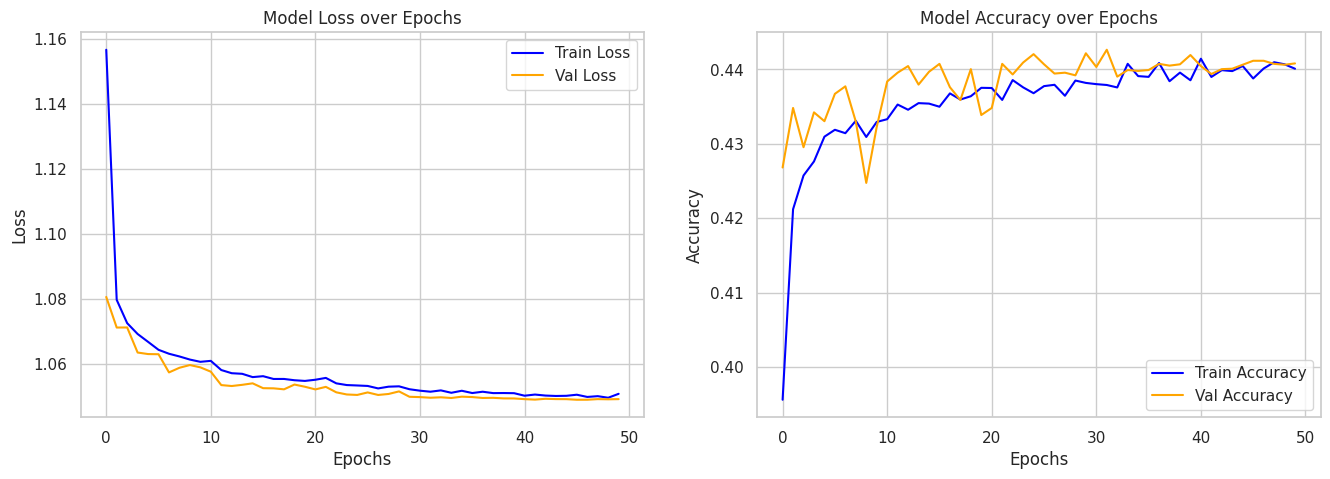

In [ ]:
# Plot training & validation loss and accuracy
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# Loss plot
ax1.plot(history.history['loss'], label='Train Loss', color='blue')
ax1.plot(history.history['val_loss'], label='Val Loss', color='orange')
ax1.set_title('Model Loss over Epochs')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Loss')
ax1.legend()

# Accuracy plot
ax2.plot(history.history['accuracy'], label='Train Accuracy', color='blue')
ax2.plot(history.history['val_accuracy'], label='Val Accuracy', color='orange')
ax2.set_title('Model Accuracy over Epochs')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Accuracy')
ax2.legend()

os.makedirs(plots_dir_path, exist_ok=True)
plt.savefig(Path(plots_dir_path) / "mlp_learning_curves.png", dpi=150)
plt.show()

## 9. Evaluation & Error Analysis
Let's evaluate the trained MLP on the hold-out test set and compare it to the baseline Logistic Regression model.

In [ ]:
# Predictions
mlp_probs = mlp_model.predict(X_test)
mlp_preds = np.argmax(mlp_probs, axis=1)

# Metrics
mlp_test_acc = accuracy_score(y_test, mlp_preds)
mlp_test_macro_f1 = f1_score(y_test, mlp_preds, average='macro')

print(f"MLP Test Accuracy: {mlp_test_acc:.4f}")
print(f"MLP Test Macro F1-score: {mlp_test_macro_f1:.4f}\n")
print("Classification Report (MLP):")
print(classification_report(y_test, mlp_preds, target_names=['Low', 'Medium', 'High']))

528/528 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
MLP Test Accuracy: 0.4463
MLP Test Macro F1-score: 0.4083

Classification Report (MLP):
              precision    recall  f1-score   support

         Low       0.44      0.74      0.55      6286
      Medium       0.44      0.35      0.39      5069
        High       0.52      0.20      0.29      5530

    accuracy                           0.45     16885
   macro avg       0.46      0.43      0.41     16885
weighted avg       0.46      0.45      0.42     16885



### 9.1 Confusion Matrix Comparison
We plot the confusion matrices side-by-side to analyze where the models make errors.

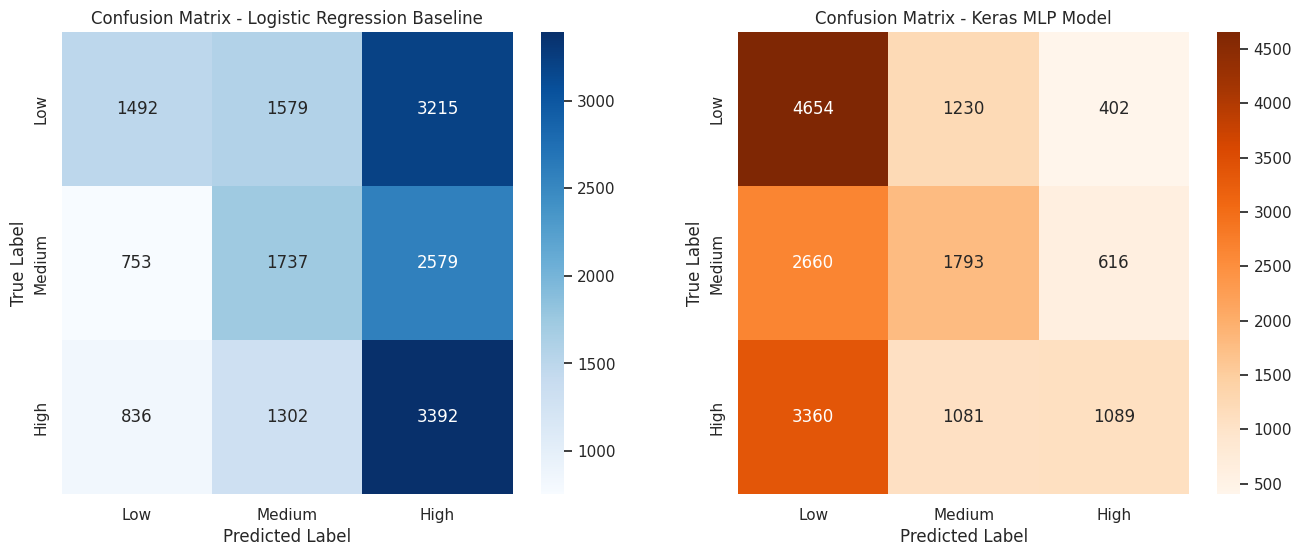

In [ ]:
cm_baseline = confusion_matrix(y_test, baseline_test_preds)
cm_mlp = confusion_matrix(y_test, mlp_preds)
classes = ['Low', 'Medium', 'High']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Baseline heatmap
sns.heatmap(cm_baseline, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes, ax=ax1)
ax1.set_title('Confusion Matrix - Logistic Regression Baseline')
ax1.set_xlabel('Predicted Label')
ax1.set_ylabel('True Label')

# MLP heatmap
sns.heatmap(cm_mlp, annot=True, fmt='d', cmap='Oranges', xticklabels=classes, yticklabels=classes, ax=ax2)
ax2.set_title('Confusion Matrix - Keras MLP Model')
ax2.set_xlabel('Predicted Label')
ax2.set_ylabel('True Label')

plt.savefig(Path(plots_dir_path) / "confusion_matrix_comparison.png", dpi=150)
plt.show()

### 9.2 Error Analysis Findings
Let's look at a summary comparison between the Logistic Regression baseline and Keras MLP.

In [ ]:
comparison_df = pd.DataFrame({
    'Metric': ['Test Accuracy', 'Test Macro F1'],
    'Logistic Regression': [baseline_test_acc, baseline_test_macro_f1],
    'Keras MLP': [mlp_test_acc, mlp_test_macro_f1]
})
print(comparison_df.to_string(index=False))

# Identify features where errors occur
test_analysis = test_features.copy()
test_analysis['mlp_pred'] = mlp_preds
test_analysis['correct'] = (test_analysis['rating_band'] == test_analysis['mlp_pred'])

print(f"\nMLP Correct Classification Rate: {test_analysis['correct'].mean() * 100:.2f}%")
print("\nAverage attributes for Correct vs. Incorrect Predictions:")
print(test_analysis.groupby('correct')[['price_cleaned', 'review_count', 'mean_helpful_votes']].mean())

       Metric  Logistic Regression  Keras MLP
Test Accuracy             0.392123   0.446313
Test Macro F1             0.379395   0.408314

MLP Correct Classification Rate: 44.63%

Average attributes for Correct vs. Incorrect Predictions:
         price_cleaned  review_count  mean_helpful_votes
correct                                                 
False        18.217445      6.160659            0.558319
True         18.799510      6.522956            0.647700
